# 使用 VIA 进行轨迹推断

VIA（Velocity and Topology Inference Algorithm）是一种单细胞轨迹推断方法，可以同时完成轨迹拓扑构建、伪时间估计、终末状态自动识别，以及沿谱系的基因动态可视化。本教程基于 VIA 作者提供的示例数据和分析流程，并在 OmicVerse 中提供更贴近 `AnnData` 使用习惯的包装接口。

如果在研究中使用 VIA，请引用：

[Generalized and scalable trajectory inference in single-cell omics data with VIA](https://www.nature.com/articles/s41467-021-25773-3)

代码仓库：<https://github.com/ShobiStassen/VIA>

Colab 可复现教程：<https://colab.research.google.com/drive/1A2X23z_RLJaYLbXaiCbZa-fjNbuGACrD?usp=sharing>

In [1]:
%matplotlib inline

from pathlib import Path
import warnings

import scanpy as sc
import matplotlib.pyplot as plt
import omicverse as ov

warnings.filterwarnings("ignore", category=FutureWarning)

ov.plot_set(font_path='Arial')
Path("figures").mkdir(exist_ok=True)

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 数据加载与预处理

本教程使用 VIA 作者提供的 `scRNA_hematopoiesis` 造血发育数据集。该数据已经完成标准化和对数转换，但尚未进行 scaling。载入数据后，我们先计算 PCA，后续 VIA 会使用 `adata.obsm["X_pca"]` 作为细胞特征空间。

In [2]:
adata = ov.single.scRNA_hematopoiesis()
sc.tl.pca(adata, svd_solver='arpack', n_comps=200)
adata

Cell type B_a1 has  27 cells
Cell type GMP has  28 cells
Cell type MEP has  339 cells
Cell type ERY1 has  773 cells
Cell type PRE_B3 has  2 cells
Cell type B_a4 has  8 cells
Cell type PRE_B2 has  515 cells
Cell type ERY4 has  53 cells
Cell type GRAN1 has  3 cells
Cell type BASO1 has  2 cells
Cell type EOS2 has  3 cells
Cell type HSC2 has  10 cells
Cell type mDC (cDC) has  96 cells
Cell type ERY3 has  104 cells
Cell type MEGA1 has  12 cells
Cell type B_a2 has  1 cells
Cell type MONO2 has  35 cells
Cell type pDC has  204 cells
Cell type TCEL7 has  1 cells
Cell type MONO1 has  186 cells
Cell type HSC1 has  2365 cells
Cell type ERY2 has  40 cells
Cell type CMP has  968 cells
Cell type Nka3 has  5 cells


AnnData object with n_obs × n_vars = 5780 × 14651
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'label'
    uns: 'cluster_colors', 'ct_colors', 'palantir_branch_probs_cell_types', 'pca'
    obsm: 'tsne', 'MAGIC_imputed_data', 'palantir_branch_probs', 'X_pca'
    varm: 'PCs'

## 构建并运行 VIA 模型

运行 VIA 时需要指定用于轨迹推断的细胞特征矩阵，例如 `X_pca`、`X_scVI` 或 `X_glue`。这里使用 `X_pca`，并通过 `adata_ncomps=80` 指定前 80 个主成分。

还需要指定用于着色和图结构汇总的细胞注释列 `clusters`。本教程使用 `adata.obs["label"]`。如果不提供 `root_user`，VIA 会尝试自动选择根细胞；这里为了复现作者示例，显式指定根细胞索引。二维展示坐标由 `basis` 指定，本数据集中可使用 `adata.obsm["tsne"]`。

更多参数说明可参考 VIA 文档：<https://pyvia.readthedocs.io/en/latest/Parameters%20and%20Attributes.html>

In [3]:
v0 = ov.single.pyVIA(
    adata=adata,
    adata_key='X_pca',
    adata_ncomps=80,
    basis='tsne',
    clusters='label',
    knn=30,
    random_seed=4,
    root_user=[4823],
)

v0.run()

via_marker_lineages = list(v0.model.terminal_clusters)[:2]
via_heatmap_lineages = via_marker_lineages[:1]
print(f"Selected terminal lineages: {via_marker_lineages}")

2026-05-23 00:35:19.967832	Running VIA over input data of 5780 (samples) x 80 (features)
2026-05-23 00:35:19.967913	Knngraph has 30 neighbors
2026-05-23 00:35:22.271938	Finished global pruning of 30-knn graph used for clustering at level of 0.15. Kept 46.3 % of edges. 
2026-05-23 00:35:22.285443	Number of connected components used for clustergraph  is 1
2026-05-23 00:35:22.421842	Commencing community detection
2026-05-23 00:35:22.788173	Finished community detection. Found 207 clusters.
2026-05-23 00:35:22.789278	Merging 189 very small clusters (<10)
2026-05-23 00:35:22.790632	Finished detecting communities. Found 18 communities
2026-05-23 00:35:22.790796	Making cluster graph. Global cluster graph pruning level: 0.15
2026-05-23 00:35:22.799106	Graph has 1 connected components before pruning
2026-05-23 00:35:22.799869	Graph has 2 connected components after pruning
2026-05-23 00:35:22.800252	Graph has 1 connected components after reconnecting
2026-05-23 00:35:22.800414	0.0% links trimmed 

  0%|                                                                                                         …

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


memory for rw2 hittings times  2. Using rw2 based pt
2026-05-23 00:35:30.092010	Identifying terminal clusters corresponding to unique lineages...
2026-05-23 00:35:30.092025	Closeness:[3, 5, 7, 9, 12, 14]
2026-05-23 00:35:30.092031	Betweenness:[1, 2, 3, 4, 7, 9, 10, 12, 14, 15, 16]
2026-05-23 00:35:30.092036	Out Degree:[3, 4, 5, 9, 10, 12, 14, 15, 16]
2026-05-23 00:35:30.092096	Cluster 5 had 3 or more neighboring terminal states [7, 9, 16] and so we removed cluster 7
2026-05-23 00:35:30.092111	We removed cluster 10 from the shortlist of terminal states
2026-05-23 00:35:30.092160	Terminal clusters corresponding to unique lineages in this component are [3, 4, 5, 9, 12, 14, 15, 16] 
2026-05-23 00:35:30.092168	Calculating lineage probability at memory 5


  0%|                                                                                                         …

2026-05-23 00:35:31.766889	Cluster or terminal cell fate 3 is reached 19.0 times
2026-05-23 00:35:31.783154	Cluster or terminal cell fate 4 is reached 423.0 times
2026-05-23 00:35:31.798511	Cluster or terminal cell fate 5 is reached 84.0 times
2026-05-23 00:35:31.811931	Cluster or terminal cell fate 9 is reached 84.0 times
2026-05-23 00:35:31.823678	Cluster or terminal cell fate 12 is reached 416.0 times
2026-05-23 00:35:31.834526	Cluster or terminal cell fate 14 is reached 559.0 times
2026-05-23 00:35:31.845602	Cluster or terminal cell fate 15 is reached 543.0 times
2026-05-23 00:35:31.859101	Cluster or terminal cell fate 16 is reached 54.0 times
2026-05-23 00:35:31.861442	There are (8) terminal clusters corresponding to unique lineages {3: 'PRE_B2', 4: 'CMP', 5: 'ERY1', 9: 'ERY1', 12: 'MONO1', 14: 'pDC', 15: 'pDC', 16: 'ERY1'}
2026-05-23 00:35:31.861455	Begin projection of pseudotime and lineage likelihood
2026-05-23 00:35:32.785927	Cluster graph layout based on forward biasing
2026-

## 基础可视化

在后续轨迹图之前，先查看细胞注释在 tSNE 空间中的分布。

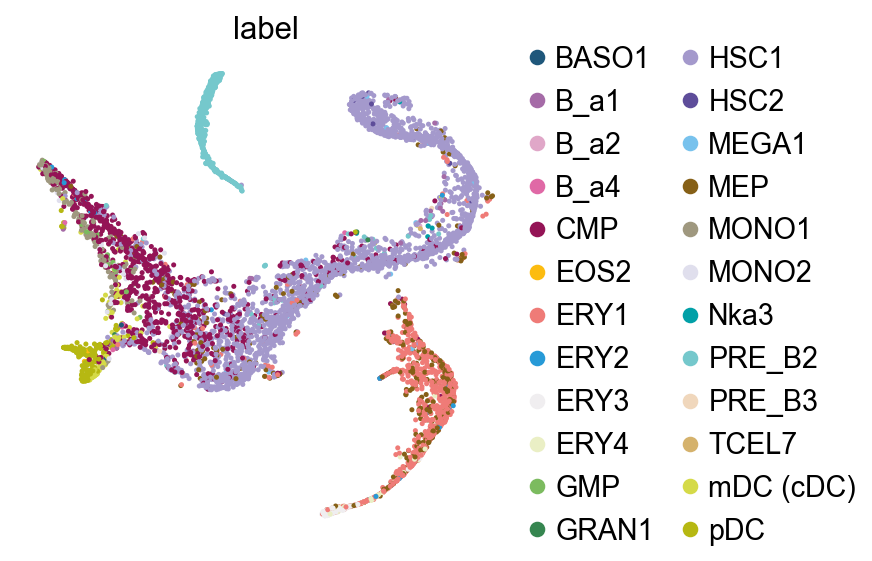

In [4]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ov.pl.embedding(
    adata,
    basis="tsne",
    color=['label'],
    frameon=False,
    ncols=1,
    wspace=0.5,
    show=False,
    ax=ax
)
fig.savefig('figures/via_fig1.png',dpi=300,bbox_inches = 'tight')

## VIA 图结构

VIA 提供多种轨迹可视化方式。这里先展示 cluster graph 层面的轨迹抽象：左图显示每个 VIA cluster 中真实注释标签的组成，右图显示 VIA 推断的伪时间。这个视图适合快速检查整体拓扑、根位置和终末分支是否符合预期。

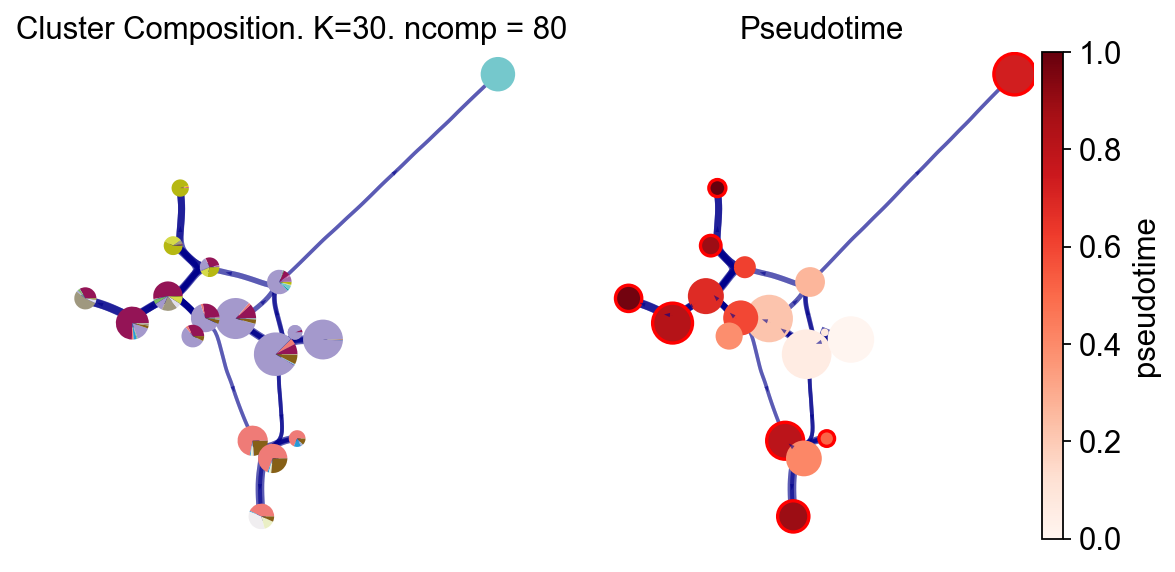

In [5]:
fig, ax, ax1 = v0.plot_piechart_graph(
    clusters='label',
    cmap='Reds',
    dpi=80,
    show_legend=False,
    ax_text=False,
    fontsize=4
)
fig.savefig('figures/via_fig2.png',dpi=300,bbox_inches = 'tight')

In [6]:
#you can use `v0.model.single_cell_pt_markov` to extract the pseudotime
v0.get_pseudotime(v0.adata)
v0.adata

...the pseudotime of VIA added to AnnData obs named `pt_via`


AnnData object with n_obs × n_vars = 5780 × 14651
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'label', 'pt_via'
    uns: 'cluster_colors', 'ct_colors', 'palantir_branch_probs_cell_types', 'pca', 'REFERENCE_MANU', 'label_colors_rgba', 'label_colors'
    obsm: 'tsne', 'MAGIC_imputed_data', 'palantir_branch_probs', 'X_pca'
    varm: 'PCs'

## 基因 / 特征图可视化

VIA 可以沿推断得到的图结构展示基因表达变化。这里使用 VIA 内部构建的 HNSW small-world graph 加速基因表达平滑，思想上类似 MAGIC 插补。随后将选定 marker 基因投影到 VIA cluster graph 上，观察不同造血程序在轨迹中的空间分布。

shape of transition matrix raised to power 3 (5780, 5780)


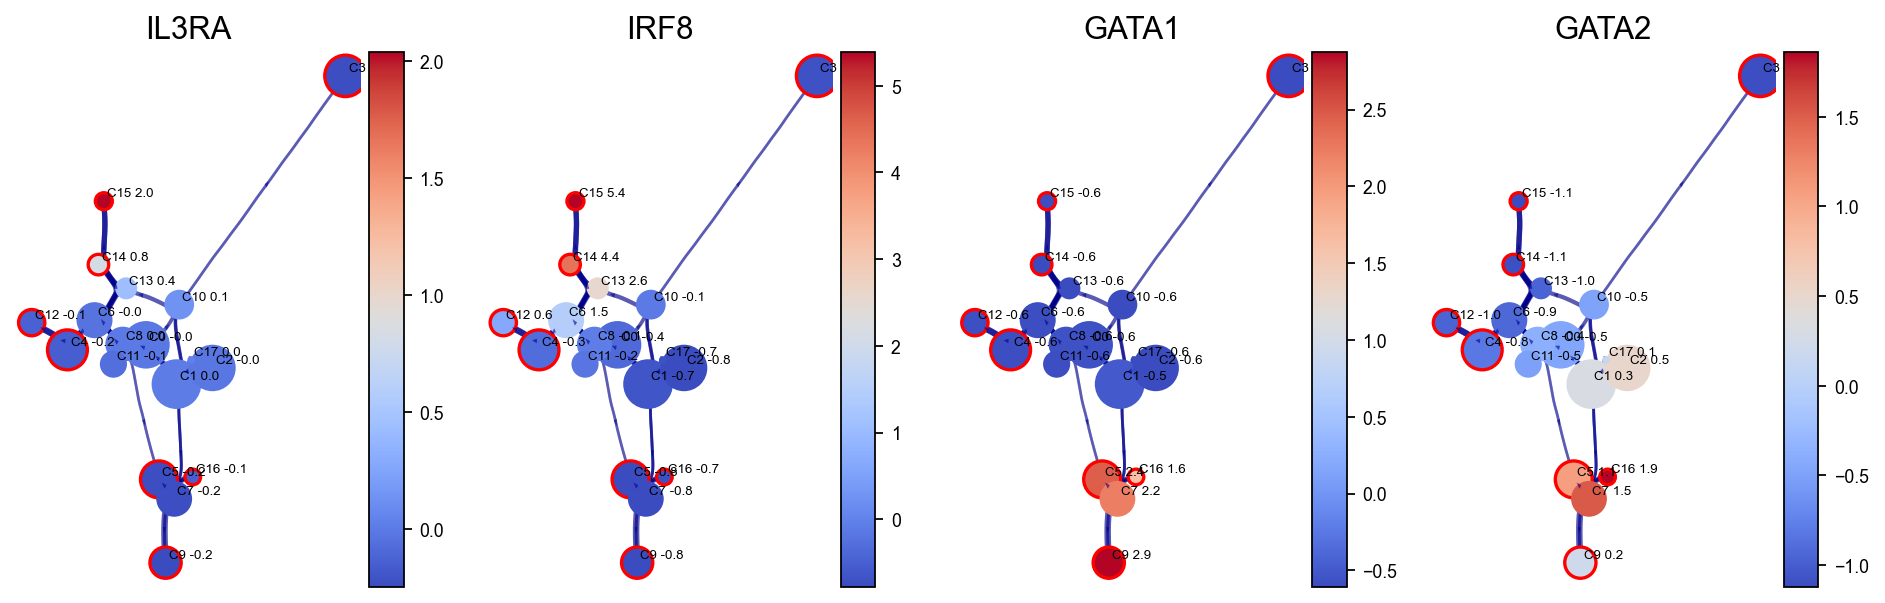

In [15]:
gene_list_magic = ['IL3RA', 'IRF8', 'GATA1', 'GATA2', 'ITGA2B', 'MPO', 'CD79B', 'SPI1', 'CD34', 'CSF1R', 'ITGAX']
fig,axs=v0.plot_clustergraph(gene_list=gene_list_magic[:4],figsize=(12,4),)
fig.savefig('figures/via_fig2_1.png',dpi=300,bbox_inches = 'tight')

## 轨迹投影

下面把 VIA 推断得到的轨迹结构投影到二维 embedding（例如 UMAP、PHATE 或 tSNE）上。这个部分包含三类视图：

- 将高层级 cluster graph 抽象叠加到 embedding 上；
- 在 embedding 上绘制更细粒度的细胞方向性向量场；
- 绘制高边分辨率的有向图或流线图。

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00

2026-05-23 00:35:43.199713	Super cluster 3 is a super terminal with sub_terminal cluster 3
2026-05-23 00:35:43.202076	Super cluster 4 is a super terminal with sub_terminal cluster 4
2026-05-23 00:35:43.202106	Super cluster 5 is a super terminal with sub_terminal cluster 5
2026-05-23 00:35:43.202127	Super cluster 9 is a super terminal with sub_terminal cluster 9
2026-05-23 00:35:43.202144	Super cluster 12 is a super terminal with sub_terminal cluster 12
2026-05-23 00:35:43.202161	Super cluster 14 is a super terminal with sub_terminal cluster 14
2026-05-23 00:35:43.202178	Super cluster 15 is a super terminal with sub_terminal cluster 15
2026-05-23 00:35:43.202197	Super cluster 16 is a super terminal with sub_terminal cluster 16


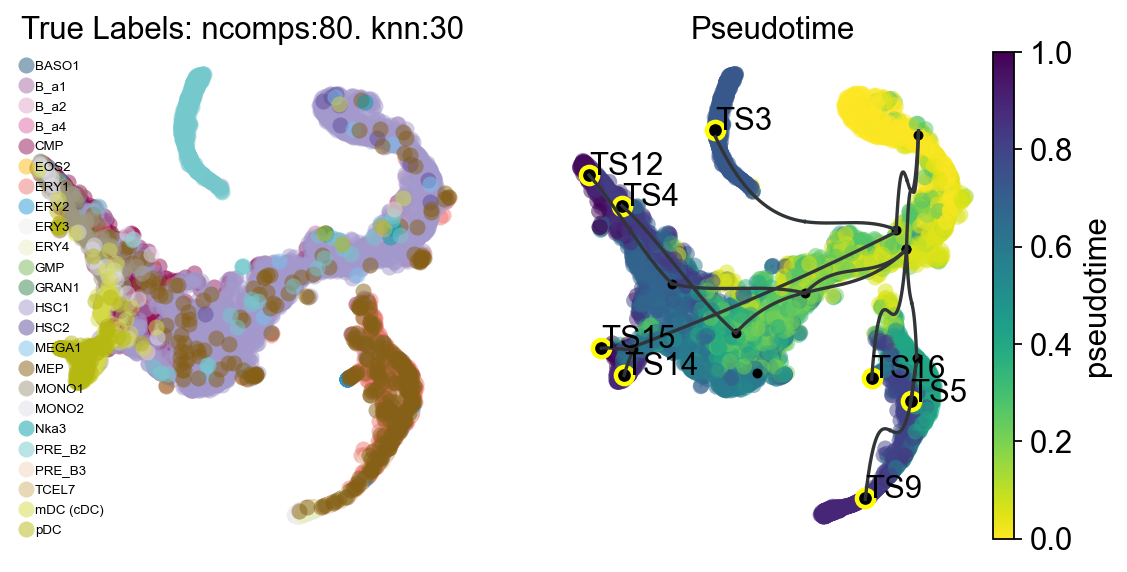

In [8]:
fig,ax1,ax2=v0.plot_trajectory_gams(basis='tsne',clusters='label',draw_all_curves=False)
fig.savefig('figures/via_fig3.png',dpi=300,bbox_inches = 'tight')

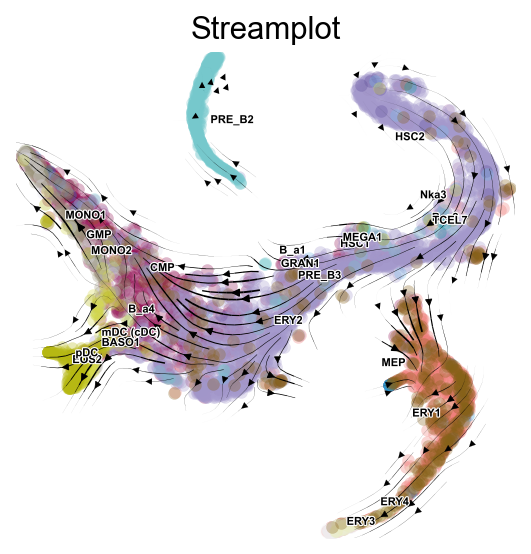

In [9]:
fig,ax=v0.plot_stream(
    basis='tsne',
    clusters='label',
    density_grid=0.8,
    scatter_size=30,
    scatter_alpha=0.3,
    linewidth=0.5
)
fig.savefig('figures/via_fig4.png',dpi=300,bbox_inches = 'tight')

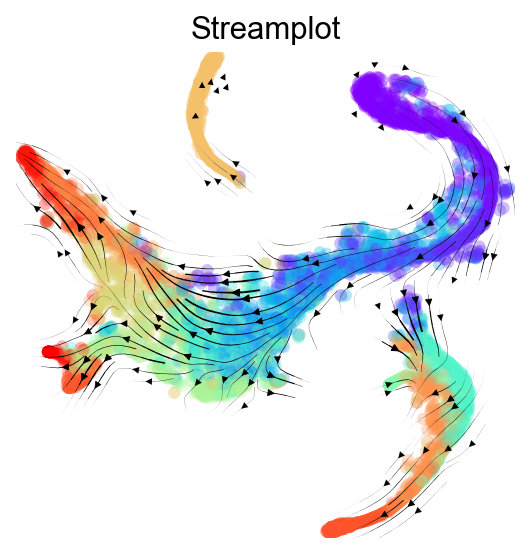

In [10]:
fig,ax=v0.plot_stream(
    basis='tsne',
    density_grid=0.8,
    scatter_size=30,
    color_scheme='time',
    linewidth=0.5,
    min_mass = 1,
    cutoff_perc = 5,
    scatter_alpha=0.3,
    marker_edgewidth=0.1,
    density_stream = 2,
    smooth_transition=1,
    smooth_grid=0.5
)
fig.savefig('figures/via_fig5.png',dpi=300,bbox_inches = 'tight')

## 概率谱系路径

VIA 会估计从根状态到各个终末状态的谱系概率。谱系概率越高，表示该细胞向对应终末状态分化的潜力越大。下面先展示所有终末谱系的概率分布。

2026-05-23 00:35:46.098394	Marker_lineages: [3, 4, 5, 9, 12, 14, 15, 16]
2026-05-23 00:35:46.099934	The number of components in the original full graph is 1
2026-05-23 00:35:46.099951	For downstream visualization purposes we are also constructing a low knn-graph 
2026-05-23 00:35:48.965546	Check sc pb 1.0 
f getting majority comp
2026-05-23 00:35:49.037414	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 3: [2, 1, 0, 8, 6, 13, 10, 3]
2026-05-23 00:35:49.037432	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 4: [2, 1, 0, 11, 4]
2026-05-23 00:35:49.037438	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 5: [2, 1, 7, 5]
2026-05-23 00:35:49.037444	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 9: [2, 1, 7, 5, 9]
2026-05-23 00:35:49.037450	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 12: [2, 1, 0, 8, 6, 12]
2026-05-23 00:35:49.037455	Cluster

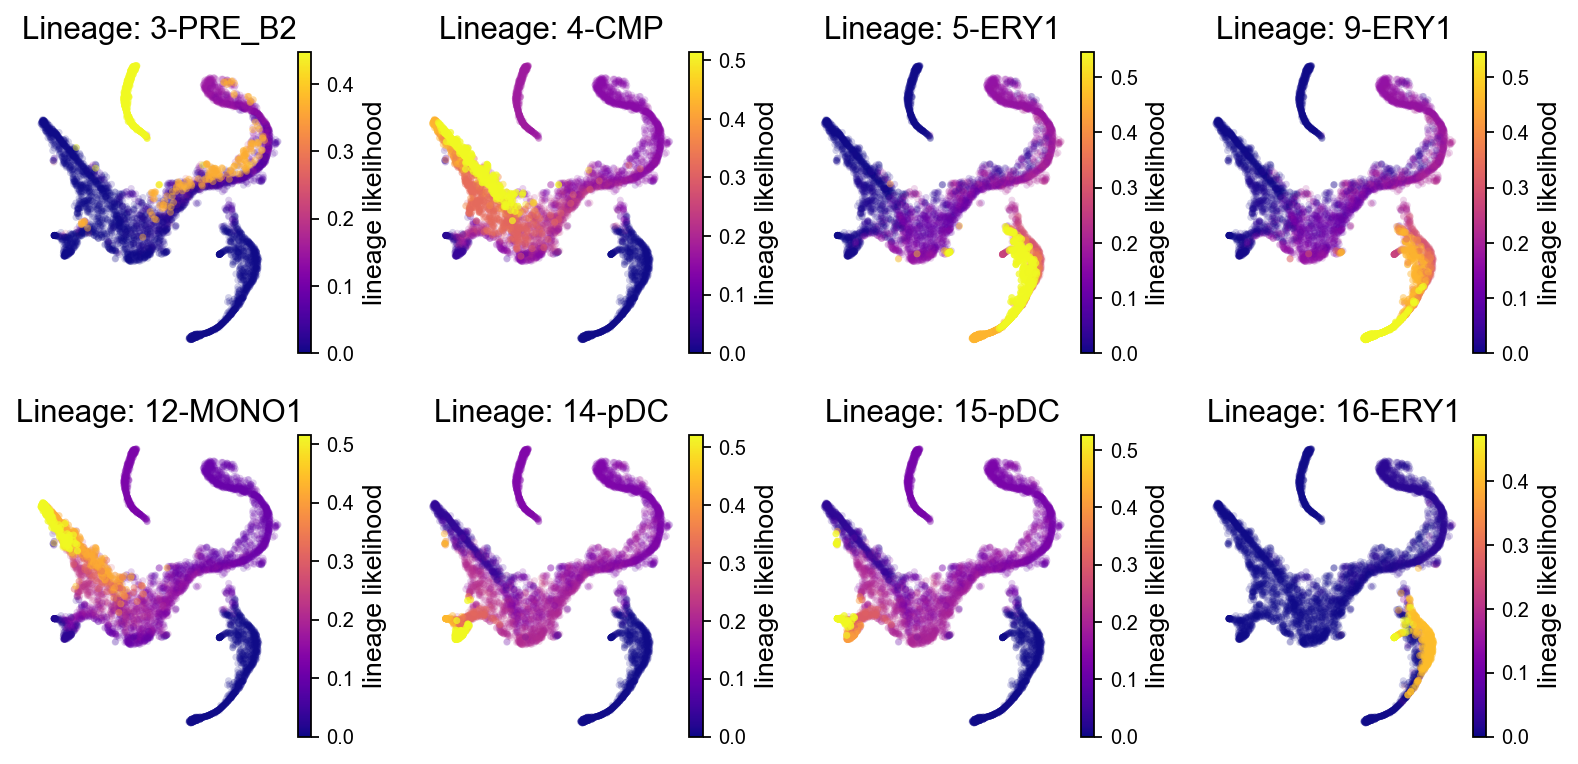

In [11]:
fig, axs = v0.plot_lineage_probability(figsize=(10, 5),ncol=4)
fig.savefig("figures/via_fig6.png", dpi=300, bbox_inches="tight")

也可以只选择部分终末谱系进行可视化。这里从模型实际识别到的终末 cluster 中取前两个谱系，避免不同版本或随机种子下 cluster 编号变化导致教程失效。

2026-05-23 00:35:50.139048	Marker_lineages: [3, 4]
2026-05-23 00:35:50.140644	The number of components in the original full graph is 1
2026-05-23 00:35:50.140673	For downstream visualization purposes we are also constructing a low knn-graph 
2026-05-23 00:35:52.890849	Check sc pb 1.0 
f getting majority comp
2026-05-23 00:35:52.962141	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 3: [2, 1, 0, 8, 6, 13, 10, 3]
2026-05-23 00:35:52.962158	Cluster path on clustergraph starting from Root Cluster 2 to Terminal Cluster 4: [2, 1, 0, 11, 4]
setting vmin to 0.0
2026-05-23 00:35:52.973994	Revised Cluster level path on sc-knnGraph from Root Cluster 2 to Terminal Cluster 3 along path: [2, 2, 2, 1, 10, 3, 3, 3, 3, 3]
setting vmin to 0.0
2026-05-23 00:35:52.981172	Revised Cluster level path on sc-knnGraph from Root Cluster 2 to Terminal Cluster 4 along path: [2, 2, 1, 4]


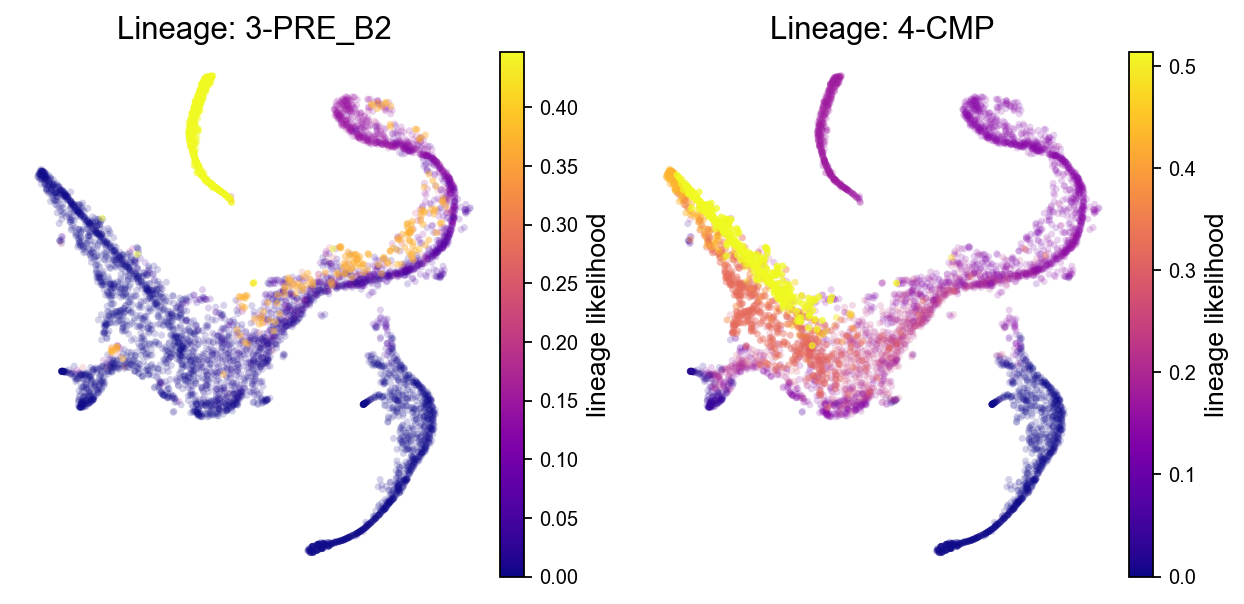

In [12]:
fig,axs=v0.plot_lineage_probability(figsize=(8,4),marker_lineages=via_marker_lineages)
fig.savefig('figures/via_fig7.png',dpi=300,bbox_inches = 'tight')

## 基因动态

VIA 会自动沿检测到的谱系推断基因表达随伪时间变化的趋势。这些曲线可以理解为特定终末谱系上 marker 基因表达程序的动态变化。最后，我们再用热图汇总选定基因在指定谱系上的趋势。

shape of transition matrix raised to power 3 (5780, 5780)


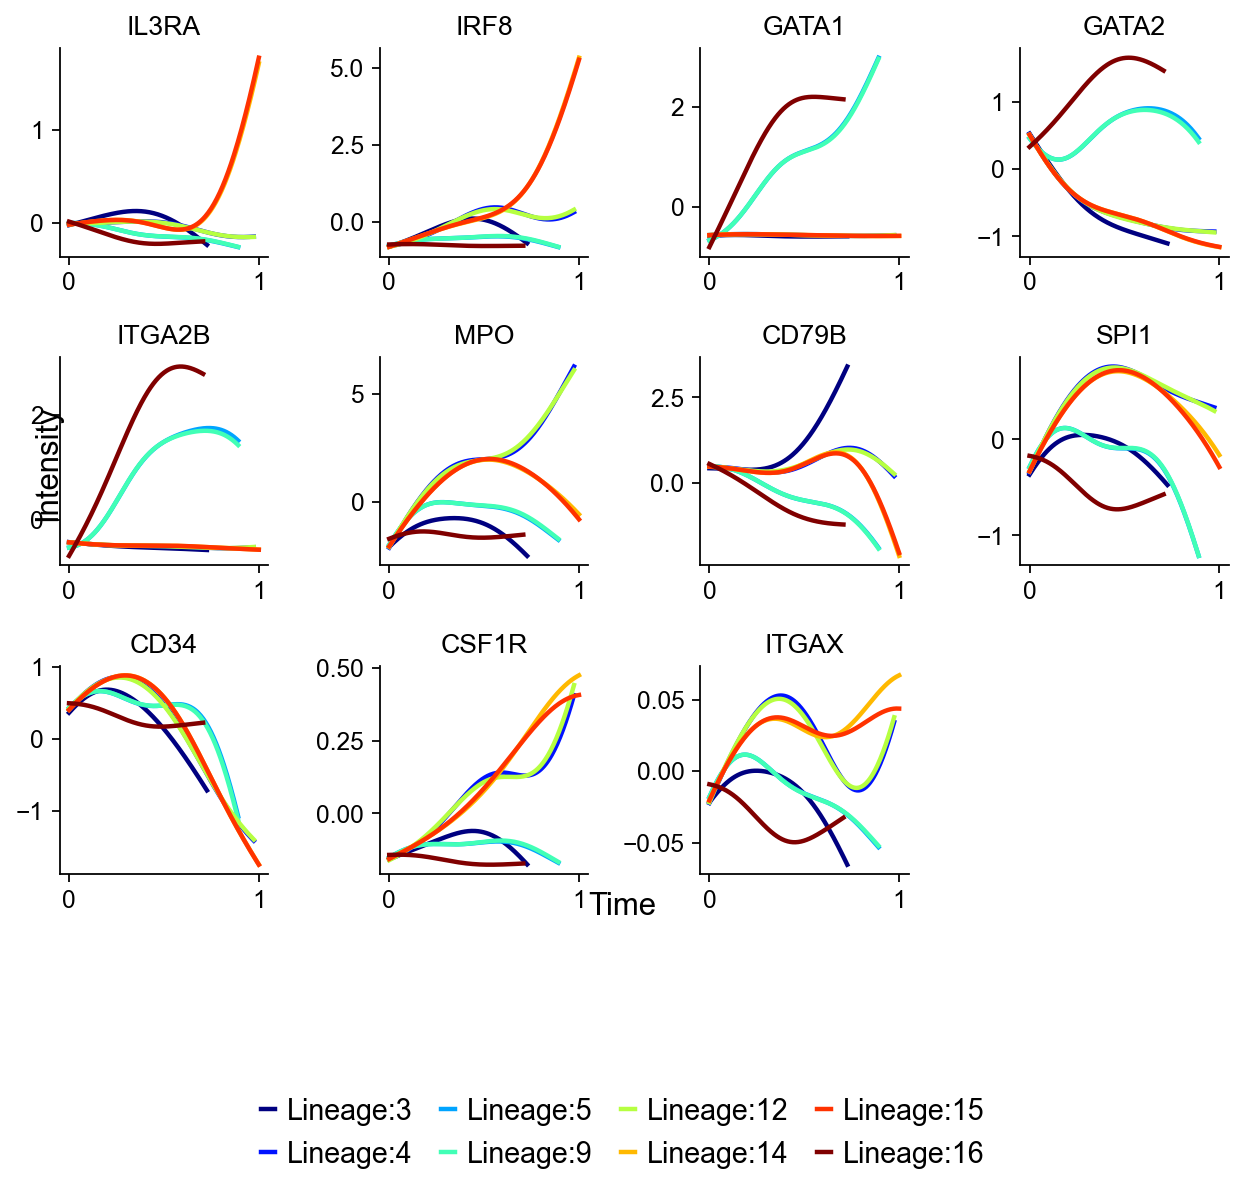

In [13]:
fig,axs=v0.plot_gene_trend(gene_list=gene_list_magic,figsize=(8,6),)
fig.savefig('figures/via_fig8.png',dpi=300,bbox_inches = 'tight')

shape of transition matrix raised to power 3 (5780, 5780)


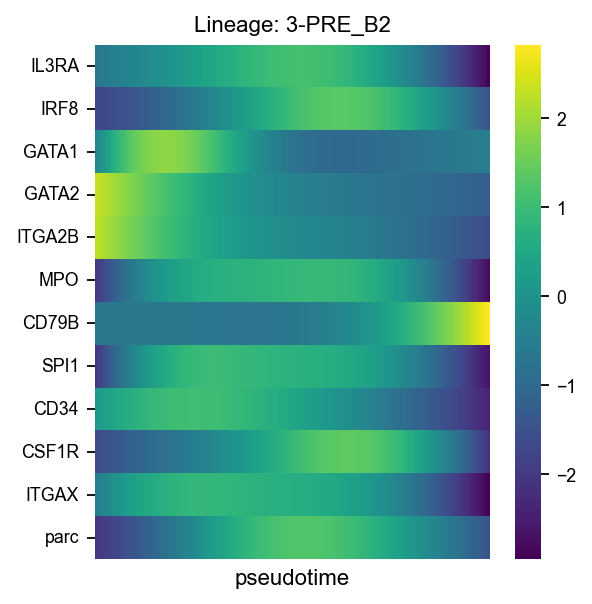

In [14]:
fig,ax=v0.plot_gene_trend_heatmap(
    gene_list=gene_list_magic,figsize=(4,4),
    marker_lineages=via_heatmap_lineages
)
fig.savefig('figures/via_fig9.png',dpi=300,bbox_inches = 'tight')